## Example Session 1  
**Session name:** `/root/capsule/data/ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28`

### Experiment  
**recording without perturbation**

### Probe targets  
- **Probe A:** MD (131 neurons in MD)
- **Probe B:** ALM (311 neurons in MOs5; 2 neurons in MOs2; 222 neurons in MOs6a) 
- **Probe C:** VP (8 neurons in SI)


### Analysis Note  
- Please filter units by regions. 

### Probe configuration
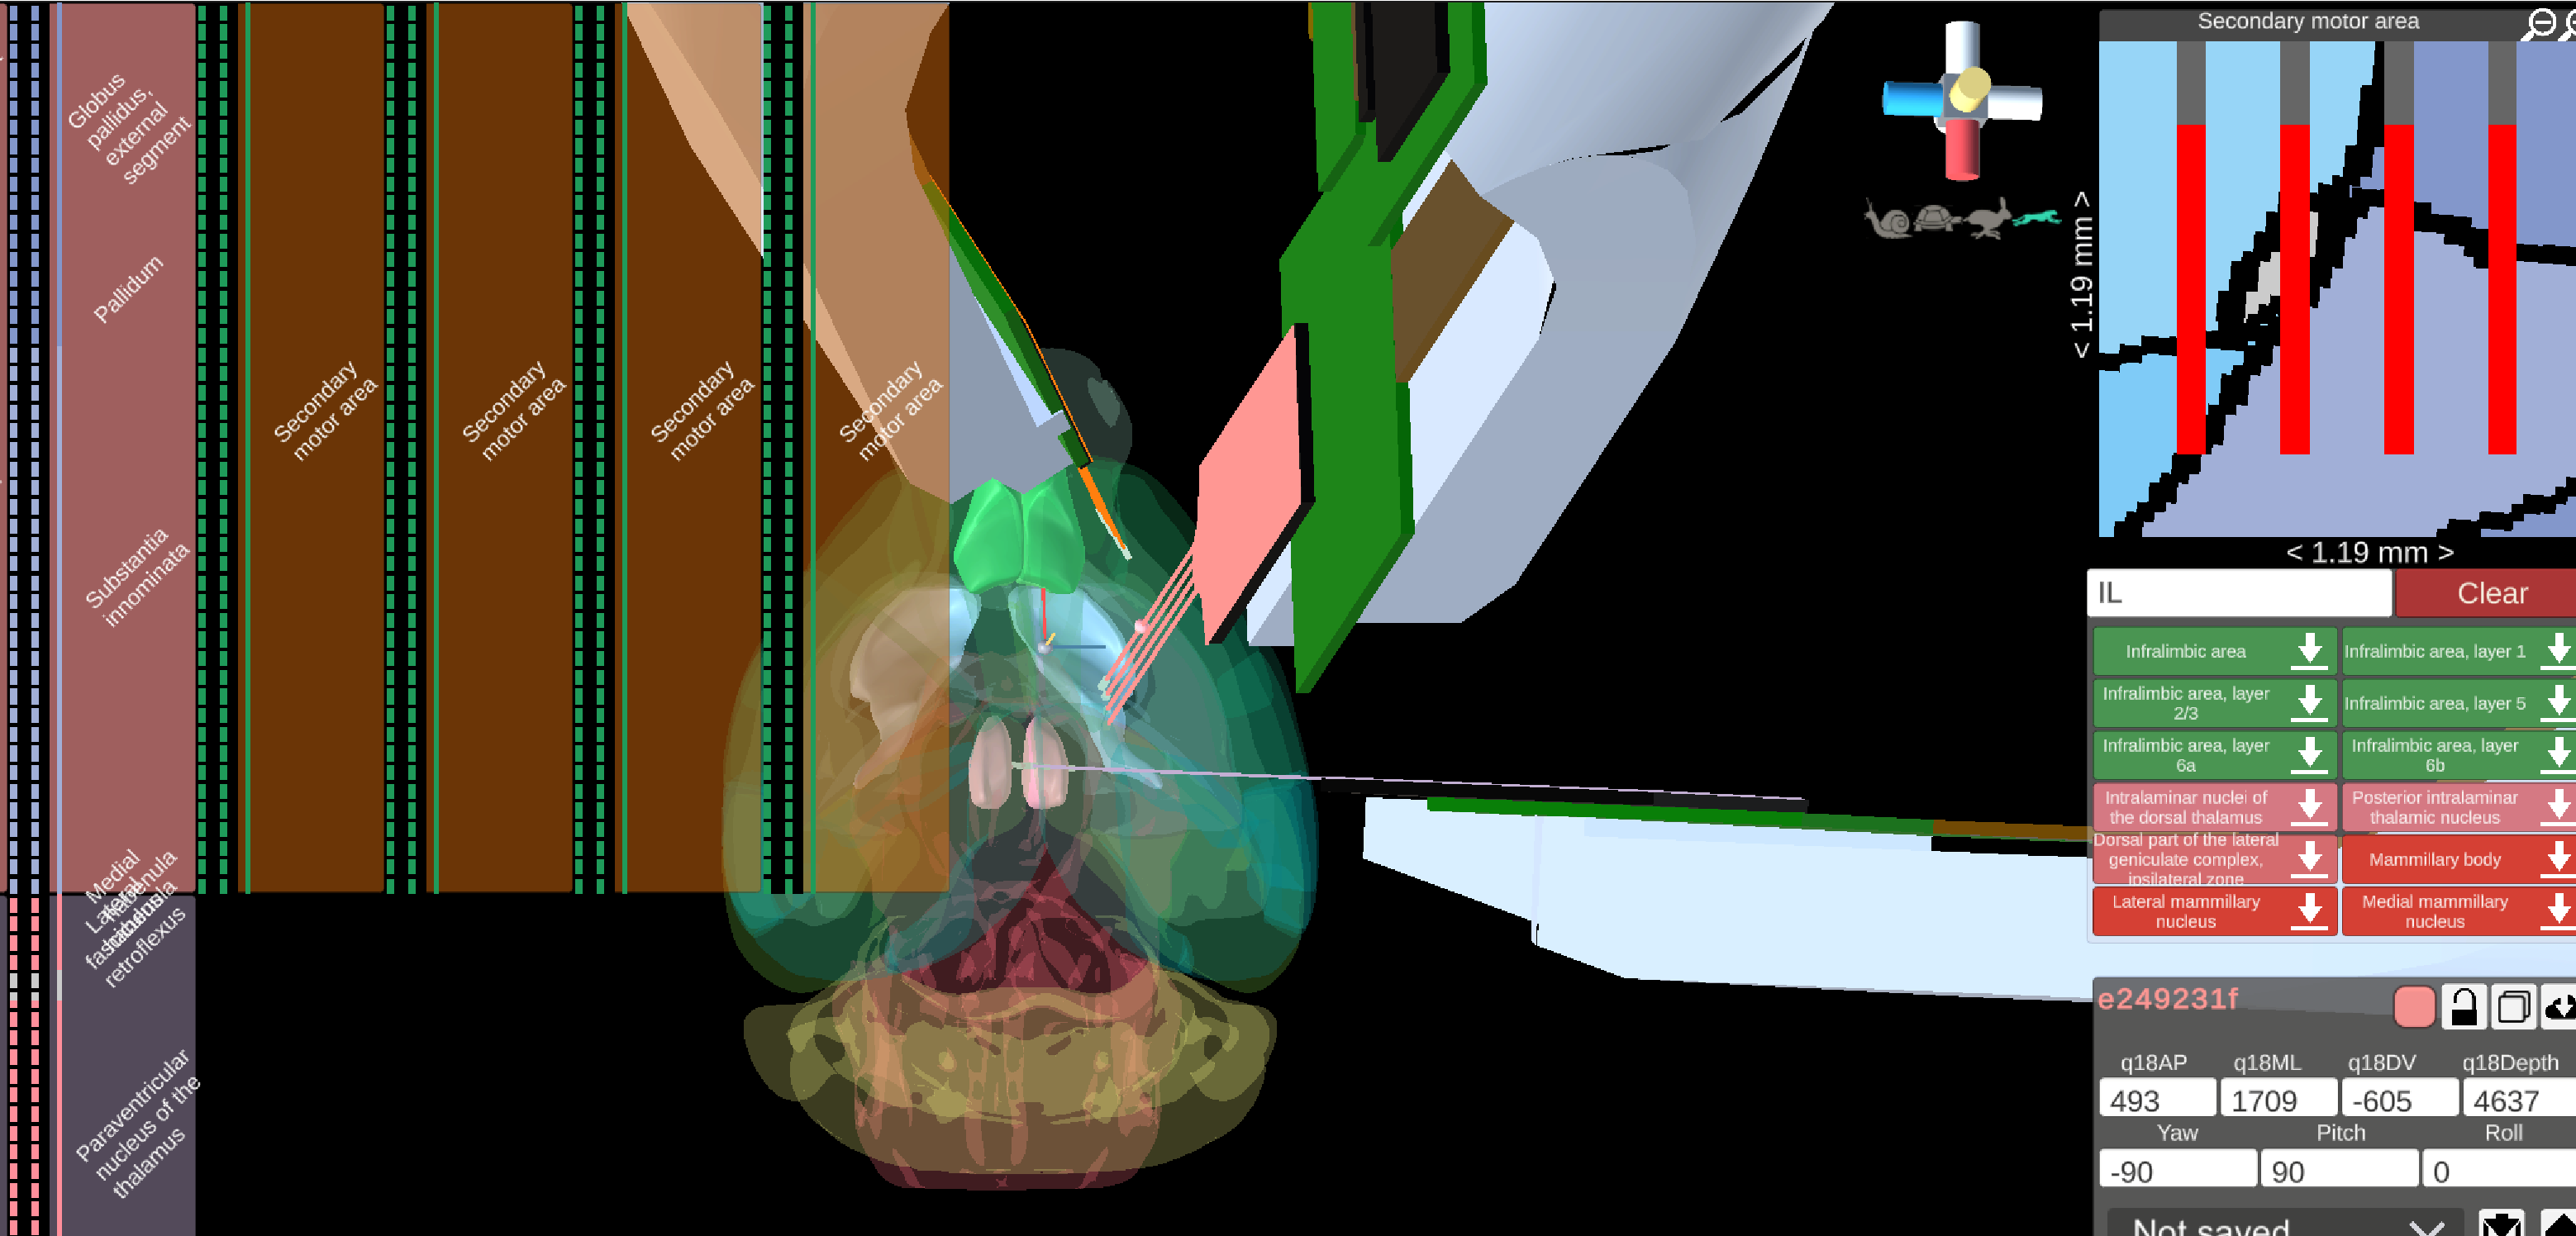





['WSLS', 'QLearning_L2F1_softmax', 'QLearning_L1F0_epsi', 'QLearning_L1F1_CK1_softmax', 'QLearning_L1F1_CKfull_softmax', 'QLearning_L2F1_CKfull_softmax', 'QLearning_L1F0_CKfull_softmax', 'ForagingCompareThreshold']
Found behavior NWB: /root/capsule/data/behavior_nwb/776293_2025-02-19_14-01-07.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/776293_2025-02-19_14-01-07.nwb
Plotting alias 'ForagingCompareThreshold' (latent: right_choice_probability)


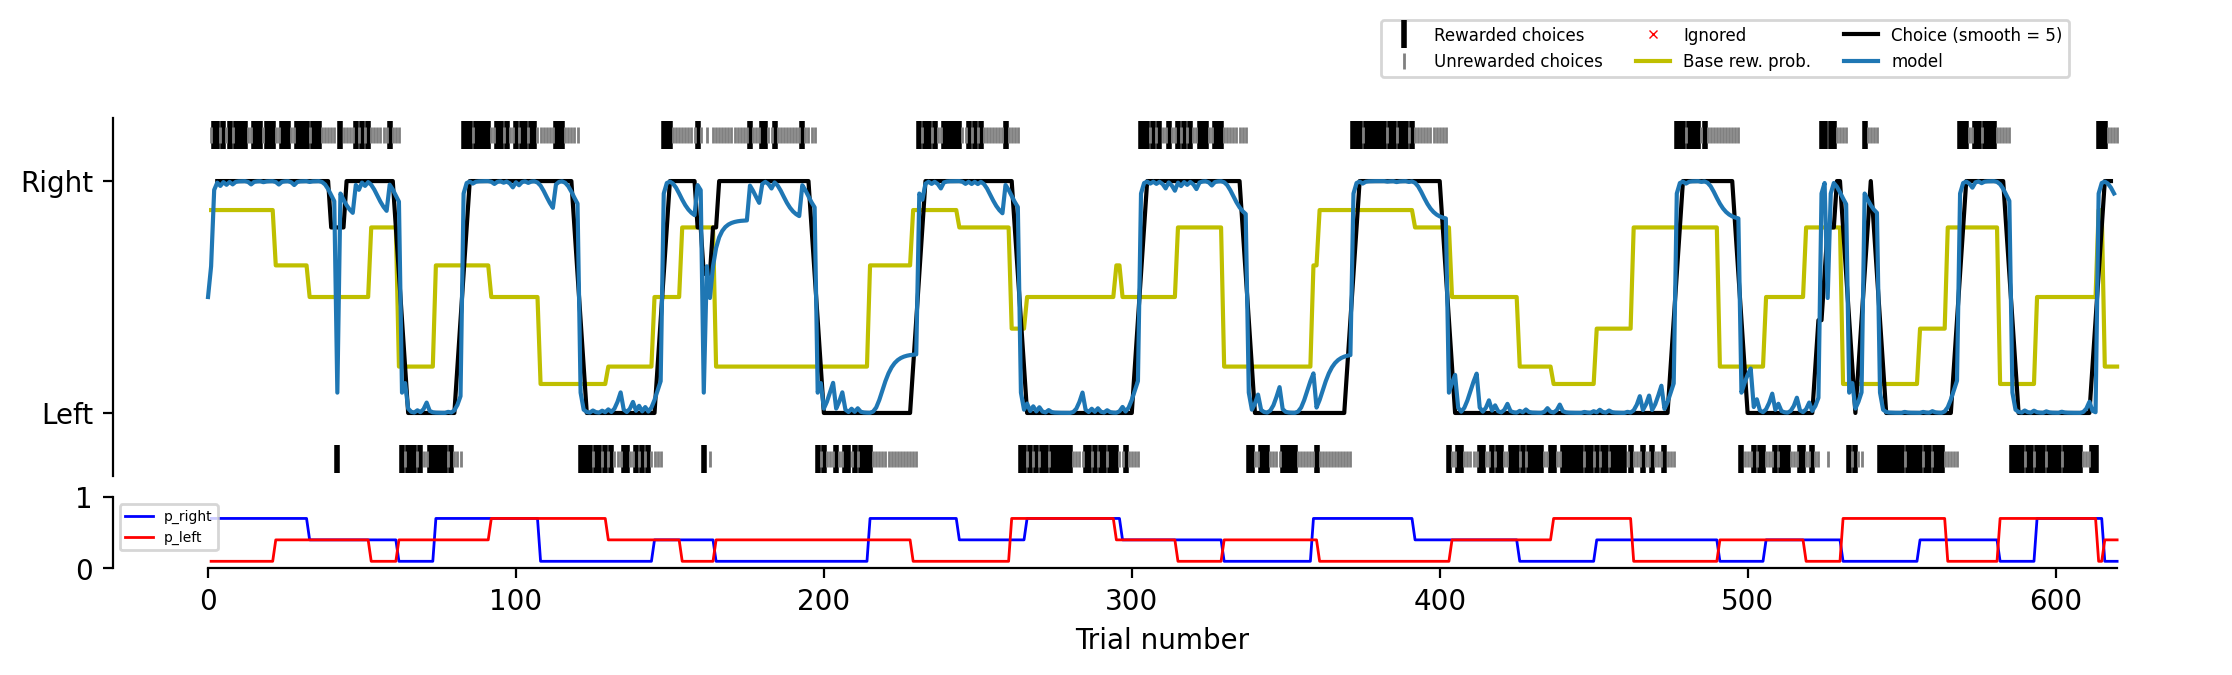

In [1]:
from general_visualization import plot_behavior_session
from nwb_utils import NWBUtils
from behavior_utils import get_fitted_model_names
import os

session_name='ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28'

behavior_sessions=[session_name]
print(get_fitted_model_names(session_name))

for behavior_session in behavior_sessions:
        nwb_data=NWBUtils.read_behavior_nwb(session_name=behavior_session)
        plot_behavior_session(nwb_data=nwb_data,model_alias='ForagingCompareThreshold',latent_name='right_choice_probability')

Found ephys NWB: /root/capsule/data/ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28/nwb/ecephys_776293_2025-02-19_14-01-07_experiment1_recording1.nwb
Successfully read ephys NWB from: /root/capsule/data/ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28/nwb/ecephys_776293_2025-02-19_14-01-07_experiment1_recording1.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/776293_2025-02-19_14-01-07.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/776293_2025-02-19_14-01-07.nwb
Successfully appended units table to behavior NWB.
Number of units passing QC: 1295


/root/capsule/src/aind_dft_ephys_analysis/ephys_behavior_visualization.py:1533: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  t_start, t_end = float(time_window[0]), float(time_window[1])


Figure saved: /root/capsule/results/session_raster_QC_776293_2025-02-19_14-01-07.json_15021864.38_15021867.30.png


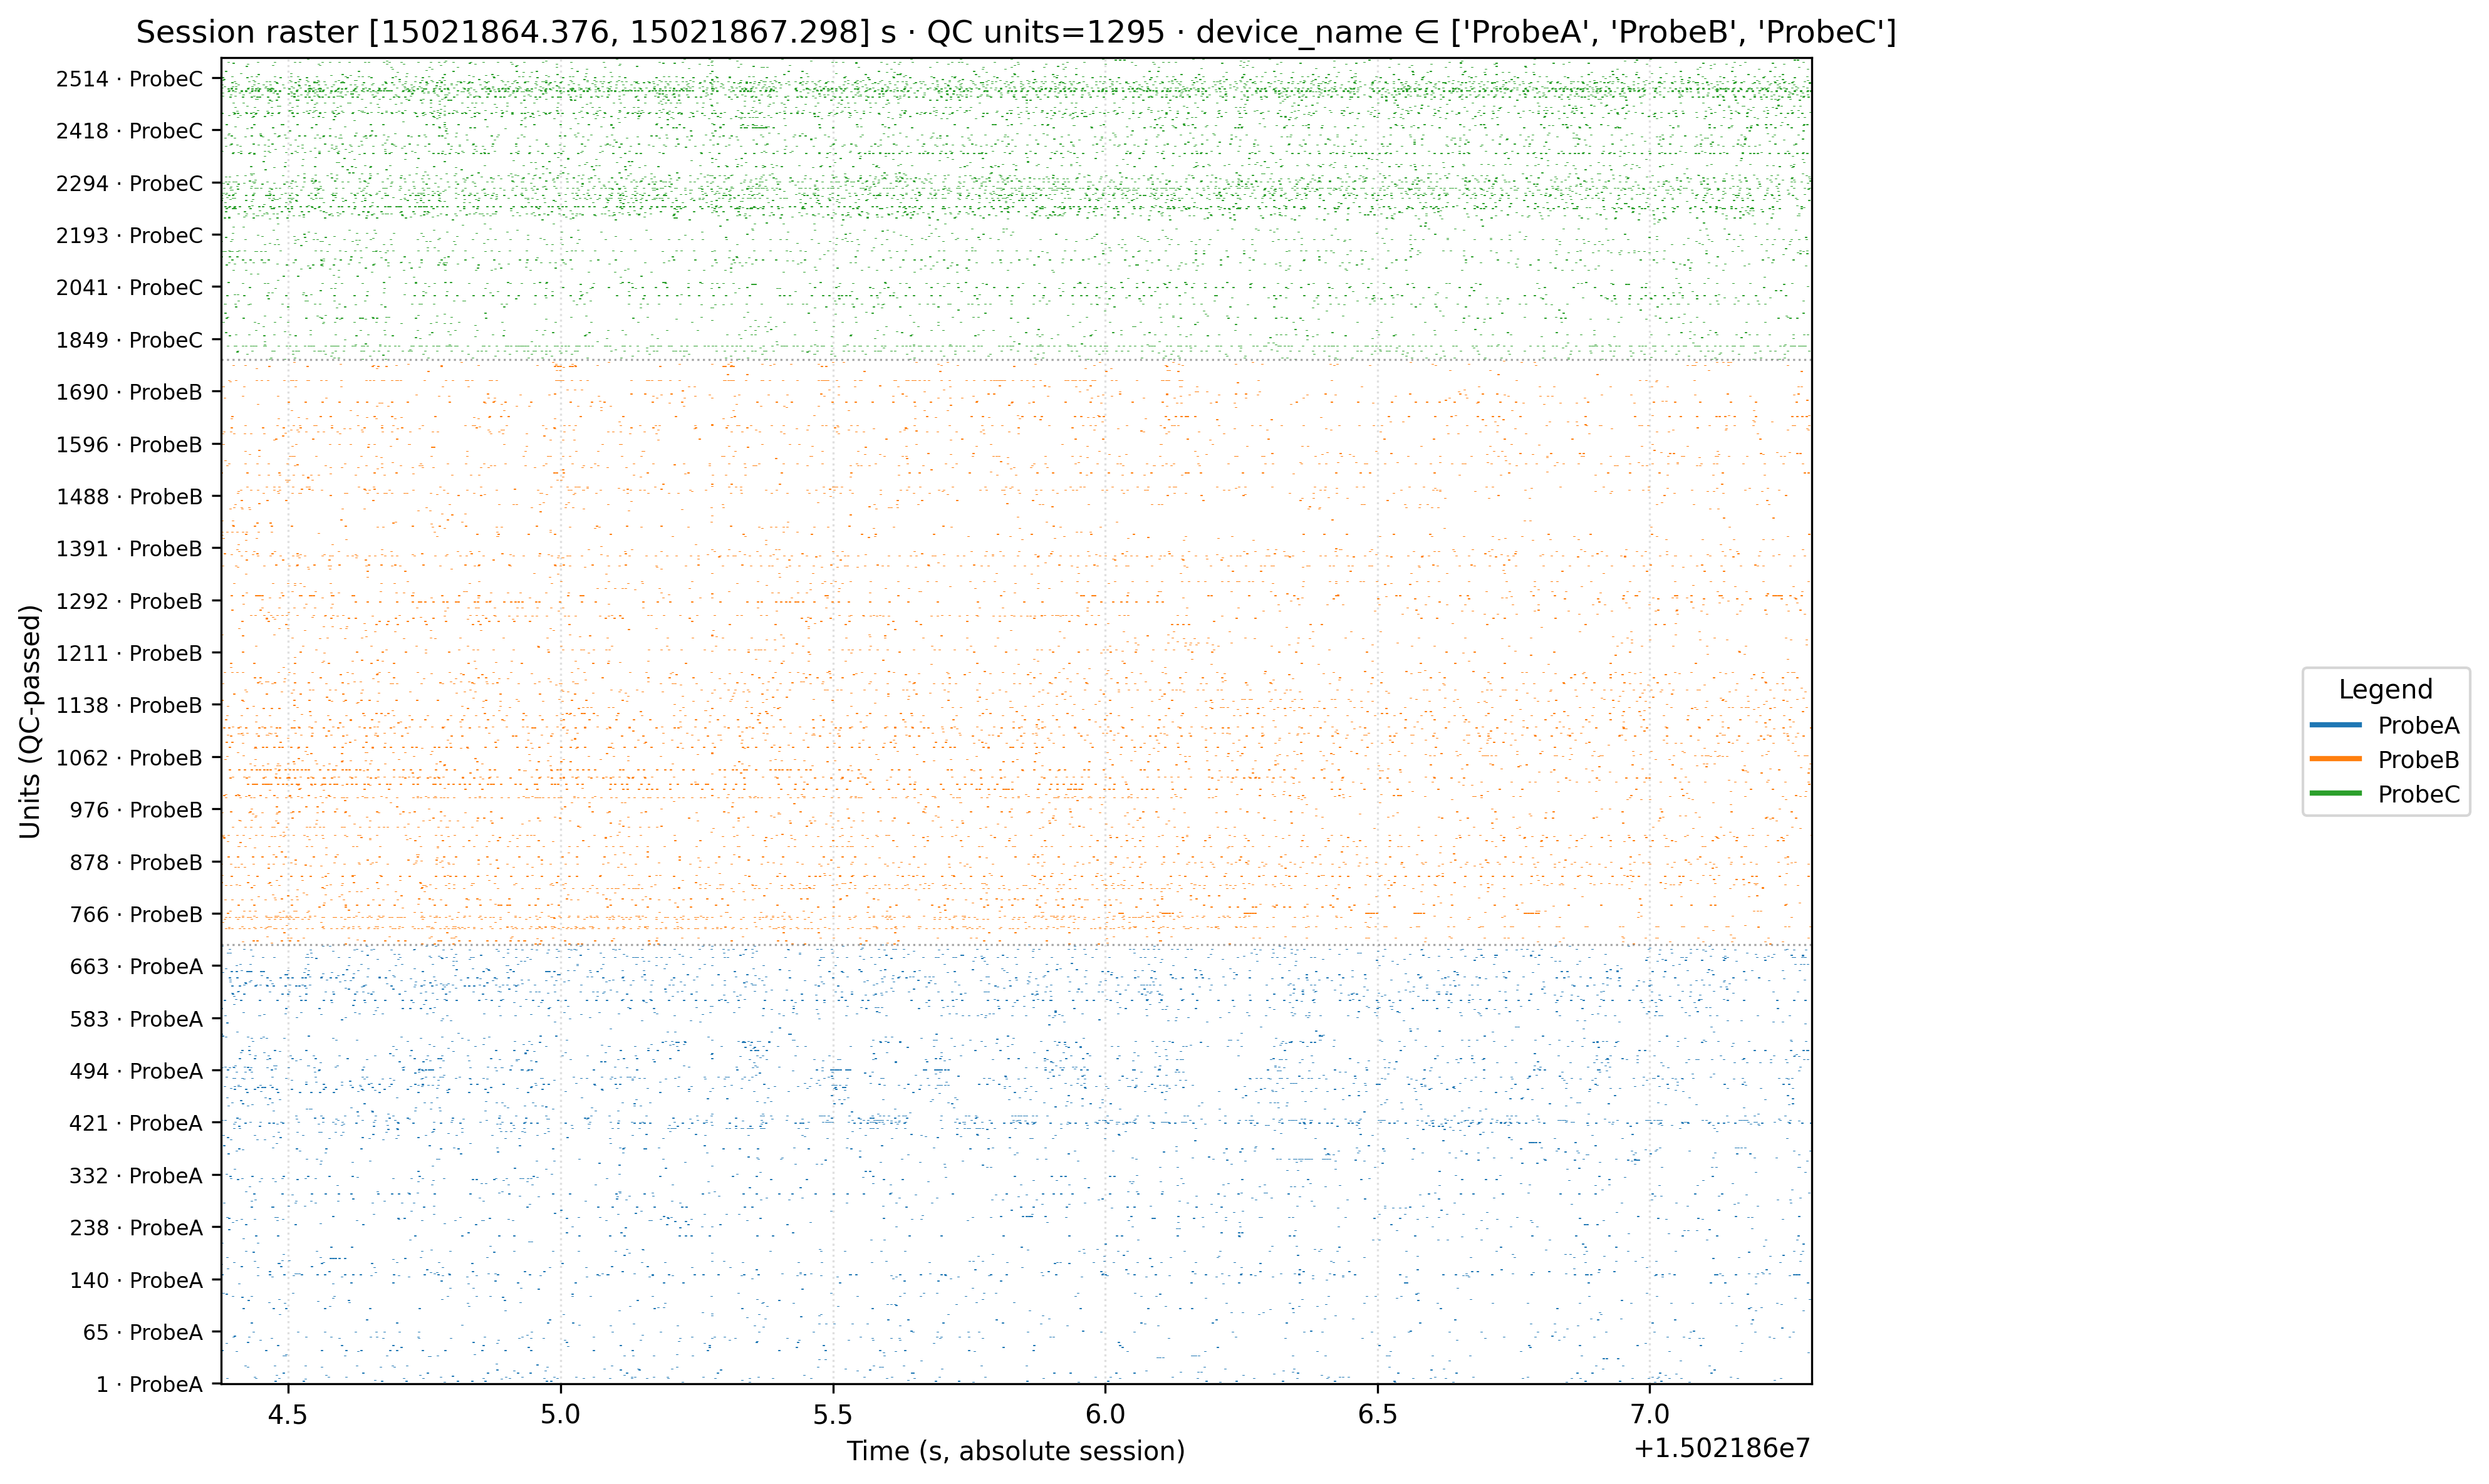

In [3]:
# show raster in a certain window
from nwb_utils import NWBUtils
from ephys_behavior_visualization import plot_session_spike_raster

nwb_data,a = NWBUtils.combine_nwb(session_name=session_name)

candidates=plot_session_spike_raster(
    nwb_data,
    time_window=(nwb_data.trials[51]['start_time']+3, nwb_data.trials[51]['stop_time']),
    probes=["ProbeA","ProbeB","ProbeC"],  
    events={"go_cue": "go_cue"},
    save_figure=True
)





In [4]:
# get units passing the default QC
from collections import Counter
from ephys_behavior import get_units_passed_default_qc
# 1) Get QC-passing unit indices
units_passing_default_qc = get_units_passed_default_qc(nwb_data)

# 2) Extract device_name for all units
device_names = nwb_data.units['device_name'][:]   # array-like

# 3) Select device names only for units that passed QC
passed_device_names = device_names[units_passing_default_qc]

# 4) Count
counts = Counter(passed_device_names)

# 5) Print nicely
print("QC-passing units per device:")
for device, count in counts.items():
    print(f"  {device}: {count}")


Number of units passing QC: 1295
QC-passing units per device:
  ProbeA: 429
  ProbeB: 571
  ProbeC: 295


In [5]:
# units location 
from pathlib import Path
from ephys_utils import append_units_locations

# 1) append units location
session_id_clean = Path(nwb_data.session_id).stem
nwb_data=append_units_locations(nwb_data,session_name=session_id_clean)


# 2) Extract ccf_location column (list of dicts, one per unit)
ccf_locations = nwb_data.units["ccf_location"][:]

# 3) Get brain_region for QC-passing units only
passed_brain_regions = []
for idx in units_passing_default_qc:
    loc = ccf_locations[idx]
    if loc is not None:
        region = loc.get("brain_region")
        if region:
            passed_brain_regions.append(region)

# 4) Count neurons per brain region
region_counts = Counter(passed_brain_regions)

# 5) Print nicely
print("QC-passing units per brain region:")
for region, count in region_counts.most_common():
    print(f"  {region}: {count}")


QC-passing units per brain region:
  MOs5: 311
  MOs6a: 222
  LPO: 144
  MD: 131
  NDB: 76
  CM: 72
  root: 42
  IAM: 38
  LHA: 37
  IAD: 31
  PVT: 25
  PAL: 10
  IMD: 9
  SO: 8
  SI: 8
  V3: 6
  opt: 4
  RH: 3
  MOs2/3: 2
  HY: 2



 Showing result_id = 0

Found folders:
   /root/capsule/data/scratch_20251219/raster_plot/ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28
Figure path: /root/capsule/data/scratch_20251219/raster_plot/ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28/QLearning_L2F1_softmax-reward_unit_1.png
Exists? True


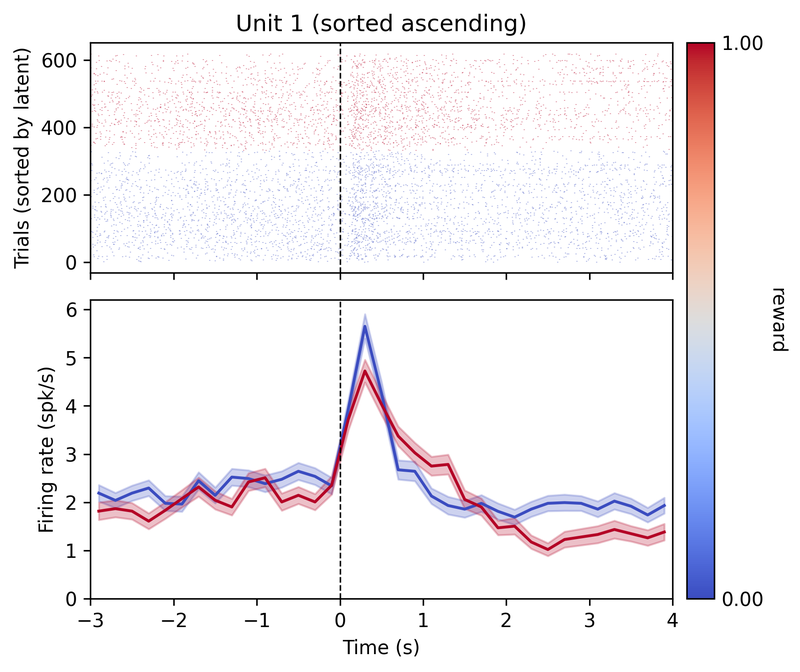


 Showing result_id = 1

Found folders:
   /root/capsule/data/scratch_20251219/raster_plot/ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28
Figure path: /root/capsule/data/scratch_20251219/raster_plot/ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28/QLearning_L2F1_softmax-reward_unit_5.png
Exists? True


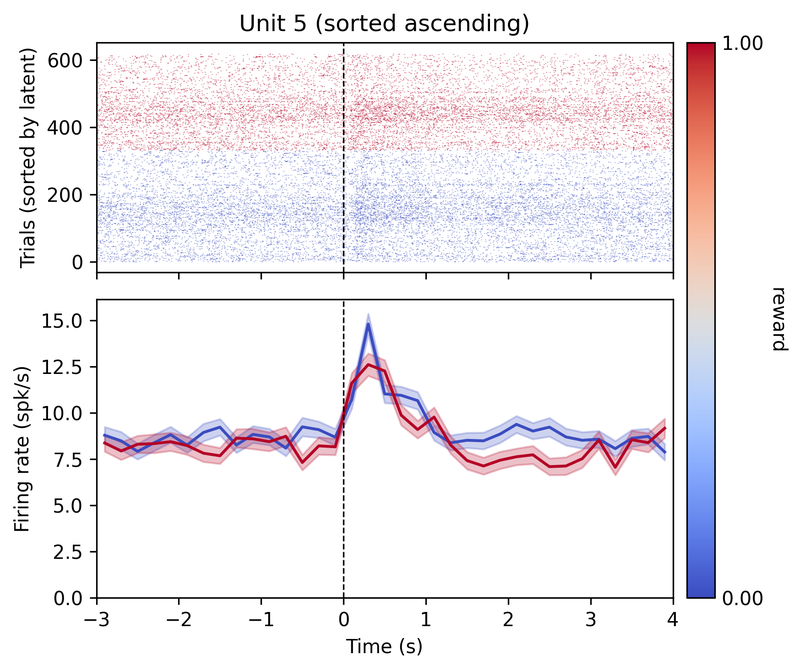

In [6]:
# visualize the single neuron activity
# --------------------------------------------------------
# COMPLETE CODE: Loop over multiple result_ids
# --------------------------------------------------------

from pathlib import Path
from PIL import Image
from IPython.display import display

# ------------------------
# Choose the list of result indices
# ------------------------

result_dicts = [{'session_id': session_id_clean, 'unit_index': 1},
 {'session_id': session_id_clean, 'unit_index': 5}]
results_ids=range(len(result_dicts))

#model_latent = "QLearning_L2F1_softmax-deltaQ-1"
#model_latent = "QLearning_L2F1_softmax-sumQ-1"
model_latent = "QLearning_L2F1_softmax-reward"

base_dir = Path("/root/capsule/data/scratch_20251219/raster_plot")

# ------------------------
# Loop over each result_id
# ------------------------
for rid in results_ids:
    print("\n===============================")
    print(f" Showing result_id = {rid}")
    print("===============================\n")

    session_id = result_dicts[rid]["session_id"]
    unit_id = result_dicts[rid]["unit_index"]

    # ------------------------
    # Locate session folder
    # ------------------------
    pattern = f"ecephys_{session_id}_sorted_*"
    session_folders = list(base_dir.glob(pattern))

    print("Found folders:")
    for f in session_folders:
        print("  ", f)

    if not session_folders:
        print(f"❌ No folder found for session_id: {session_id}")
        continue

    session_folder = session_folders[0]

    # ------------------------
    # Construct figure path
    # ------------------------
    fig_path = session_folder / f"{model_latent}_unit_{unit_id}.png"
    print("Figure path:", fig_path)
    print("Exists?", fig_path.exists())

    if not fig_path.exists():
        print(f"❌ Figure missing for: {fig_path}")
        continue

    # ------------------------
    # Load and resize image
    # ------------------------
    img = Image.open(fig_path)

    new_width = 800
    w, h = img.size
    new_height = int(h * (new_width / w))
    img_resized = img.resize((new_width, new_height), Image.LANCZOS)

    # ------------------------
    # Display resized figure
    # ------------------------
    display(img_resized)
